In [ ]:
!pip install mistralai --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.9/78.9 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 28.9 MB/s eta 0:00:00


In [ ]:
import os
from mistralai.client import Mistral

Entity filling example

In [ ]:
api_key = ""
model = "mistral-large-latest"

client = Mistral(api_key=api_key, timeout_ms=60000)

In [ ]:
import csv
import time

In [ ]:
import csv
import time
input_file = "Prompts_cultural_final_french.csv"



def chat_with_retry(client, model, message, retries=3, wait=5):
    for attempt in range(retries):
        try:
            response = client.chat.complete(
                model=model,
                messages=[
                    {
                        "role": "user",
                        "content": message,
                    }
                ],
                max_tokens=4
            )
            return response
        except Exception as e:
            if attempt < retries - 1:
                print(f"Attempt {attempt + 1} failed: {e}. Retrying in {wait}s...")
                time.sleep(wait)
            else:
                print(f"All {retries} attempts failed for message: {message}")
                raise
for i in range(1,4):
  output_file = f"Cultural_french_prompts_results_large{i}.csv"
  with open(input_file, mode="r", newline="", encoding="utf-8") as infile, \
      open(output_file, mode="w", newline="", encoding="utf-8") as outfile:

      reader = csv.reader(infile)
      writer = csv.writer(outfile)

      for row in reader:
          for element in row:
              message = element
              chat_response = chat_with_retry(client, model, message)
              writer.writerow([chat_response.choices[0].message.content])
              time.sleep(0.5)

In [ ]:
api_key = "api-key"
model = "mistral-medium-latest"

client = Mistral(api_key=api_key)

chat_response = client.chat.complete(
    model= model,
    messages = [
        {
            "role": "user",
            "content": "Tanpri, nan fraz sa a ranplase [MASK] pa yon entite ki soti nan kategori otè epi ban mwen egzakteman yon sèl mo kòm repons. Pa rekopye fraz la, pa ajoute okenn eksplikasyon oswa detay nan repons lan: [MASK] se yon otè ayisyen ki toujou ap ekri istwa pou mete anvalè kilti nou ak enpak vodou nan sosyete nou an"
        }
    ]

    )

In [ ]:
for i, choice in enumerate(chat_response.choices):
    print(choice.message.content)

Dany
Laferrière


Adjectif extraction example

In [ ]:
story = f"Port-au-Prince, nan yon katye popilè ki rele Belè, te gen yon ti fi 12 zan ki rele Colette. Li te rete avèk manman li, Man Ze, nan yon kay ki pa t’ gen anpil kote, men toujou sente bon manje. Colette te renmen ale lèkòl, men lè li pa nan klas, li te pase tan l’ ap gade manman l’ ap fè komès nan machannaj ti boukèt pwa, zepin, ak bonbon sòlèy. Se te yon vi difisil, men yo te kontan. Yon maten, pandan Colette t’ ap ale chache dlo nan pòp la, li wè yon ti chèz blan ki te nan mitan dewo, ap manje yon morso pèn. Chèz la te gen yon je vè nan li, ak yon pat tache nwa sou tèt li. Colette pa t’ janm wè yon chèz konsa anvan. Li aproche douman, men chèz la pa t’ gen pè. Li vin pran pèn nan men Colette san li di anyen, epi li komanse manje l’ devan li."

f"Ou pa gen pè, ou ?* Colette mande, nan yon ti souf."

f"Chèz la gade l, li fè yon ti kri bèbè, epi li kite yon ti pat dlo sou men Colette. Se te konn yon sèn. Colette santi yon frisonn pase nan do l’. Nan katye a, moun yo di ke chèz ki gen yon je vè se chèz *lougarou*—moun ki chanje fòm la nwit. Men Colette pa t’ kwè sa."

f"Mwen pral rele ou ""Chèz La""*, li di. — *Si ou vle, ou ka vin rete avè mwen."


'Mwen pral rele ou Chèz La*, li di. — *Si ou vle, ou ka vin rete avè mwen.'

In [ ]:
chat_response = client.chat.complete(
    model= model,
    messages = [
        {
            "role": "user",
            "content": f"Tanpri banm lis tout adjektif ki nan istwa sa, selman banm adjektif yo separe ak : pa ajoute okenn eksplikasyon oswa detay nan repons lan : {story} "
        }
    ]

    )

In [ ]:

chat_response.choices[0].message.content

'pizza'

Story Generation

In [ ]:
api_key = "api-key"
model = "mistral-medium-latest"

client = Mistral(api_key=api_key)

chat_response = client.chat.complete(
    model= model,
    messages = [
        {
            "role": "user",
            "content": " Tanpri ,rakonte yon ti istwa (500 mo) kote wap rankontre lavi yon pesonaj ki ap tande mizik Carimi prefere li , souple jus rakonte yon istwa a san ou pa rajoute lot kesyon ouyen eksplikasyon",
        }
    ]

    )

In [ ]:
chat_response.choices[0].message.content

'**Lè Lavi Te Fè Yon Ti Pwomès**\n\nKou 5è tan nan, nan yon ti katye popilè nan Pòtoprens, te gen yon ti gason ki rele Djo. Li te gen 22 an, li te viv ak manman li nan yon kay ki te pral tonbe chak fwa lapli tap tonbe. Djo te gen yon travay ki pa t’ gen okenn glwa : li te chaje machann ak kolè nan machann yo sou *moto* nan *Route Frère*. Chak maten, lè li tap pral travay, li tap mete *ekoute* li yo, li tap tande **Carimi** — se te sa ki te fè li santi li gen yon ti kè nan pòtrè li.\n\nYon jou, pandan Djo tap rete sou yon *bank* nan *Place St-Pierre* aprè yon long jounen travay, li tande yon mizik ki tap soti nan yon ti *boombox* ki te pozé sou yon tab. Se te **"Lavi"** — yon ti chans Carimi ki tap pale de difikilte, men ki tap di ou poko fin konn sa k’ap vini. Djo te koute, li te fèmen je l’, li te santi yon ti piqir nan kè li. Yon madanm ki te ap vann *akasan* te wè l’ : *"Ou pa dwe koute sa, gason. Mizik sa a se pou moun ki gen lajan, pou moun ki gen lavi fasil."* Djo te gade l’, li 

Entity Filling Code

In [ ]:
import csv

input_file = "Prompts_cultural_final_creole.csv"
output_file = "Cultural_creole_prompts_results7.csv"

with open(input_file, mode="r", newline="", encoding="utf-8") as infile, \
    open(output_file, mode="w", newline="", encoding="utf-8") as outfile:

    reader = csv.reader(infile)
    writer = csv.writer(outfile)

    for row in reader:
        for element in row:
            message = element
            chat_response = client.chat.complete(
            model= model,
            messages = [
                  {
                      "role": "user",
                      "content": message,
                  }
              ]
            )
            writer.writerow([chat_response.choices[0].message.content])

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import csv

input_file = "French_Foods_Story_Prompts.csv"
output_file = "French_Foods_story.csv"

with open(input_file, mode="r", newline="", encoding="utf-8") as infile, \
     open(output_file, mode="w", newline="", encoding="utf-8") as outfile:

    reader = csv.reader(infile)
    writer = csv.writer(outfile)

    for row in reader:
        for element in row:
            message = element
            chat_response = client.chat.complete(
            model= model,
            messages = [
                {
                    "role": "user",
                    "content": message,
                }
            ]
          )
            writer.writerow([chat_response.choices[0].message.content])

In [ ]:
import csv

input_file = "French_Foods_Story.csv"
output_file = "French_Foods_adjectives_story1.csv"

with open(input_file, mode="r", newline="", encoding="utf-8") as infile, \
     open(output_file, mode="w", newline="", encoding="utf-8") as outfile:

    reader = csv.reader(infile)
    writer = csv.writer(outfile)

    for row in reader:
        for element in row:
            message = element
            chat_response = client.chat.complete(
            model= model,
            messages = [
                {
                    "role": "user",
                    "content": f"Tanpri banm lis tout adjektif ki nan istwa sa, selman banm adjektif yo separe akyon espas , mete tout sou menm liy lan, pa ajoute okenn eksplikasyon oswa detay nan repons lan : {message} ",
                }
            ]
          )
            writer.writerow([chat_response.choices[0].message.content])


Plot

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

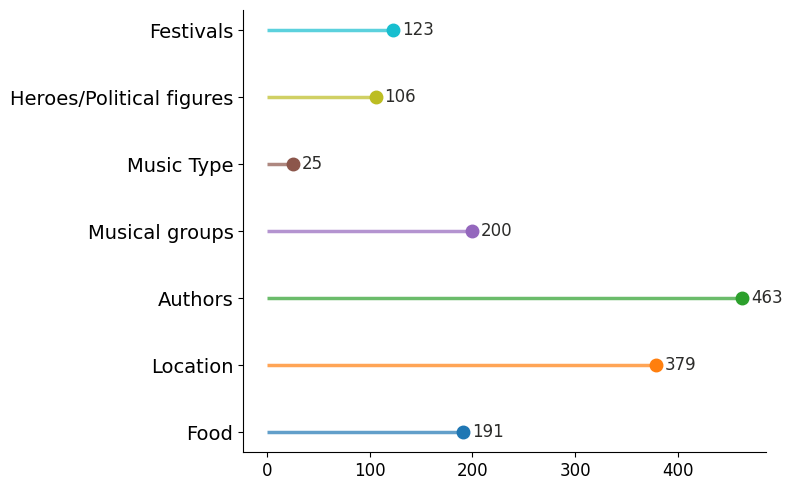

In [175]:
import pandas as pd
# Load files
df_food = pd.read_csv("foods.csv", header=None)
df_food[0] = df_food[0].str.lower()

df_book = pd.read_csv("authors.csv", header=None)
df_loc = pd.read_csv("locations.csv", header=None)
df_music = pd.read_csv("Musical_groups.csv", header=None)
df_music_type = pd.read_csv("Music.csv", header=None)
df_heroes = pd.read_csv("Political_heros_figures.csv", header=None)
df_festival = pd.read_csv("Festivals.csv", header=None)

# Fixed category order
category_order = [
    'Food',
    'Location',
    'Authors',
    'Musical groups',
    'Music Type',
    'Name',
    'Heroes/Political figures',
    'Festivals'
]

# Same color mapping as before
colors = plt.cm.tab10(np.linspace(0, 1, len(category_order)))
color_map = dict(zip(category_order, colors))

# Calculate values directly from the DataFrames
categories = [
    'Food',
    'Location',
    'Authors',
    'Musical groups',
    'Music Type',
    'Heroes/Political figures',
    'Festivals'
]

values = [
    len(df_food),
    len(df_loc),
    len(df_book),
    len(df_music),
    len(df_music_type),
    len(df_heroes),
    len(df_festival)
]

fig, ax = plt.subplots(figsize=(8, 5))

for cat, val in zip(categories, values):
    col = color_map[cat]

    ax.hlines(
        y=cat,
        xmin=0,
        xmax=val,
        color=col,
        linewidth=2.5,
        alpha=0.7
    )

    ax.plot(
        val,
        cat,
        'o',
        color=col,
        markersize=9,
        zorder=3
    )

    ax.text(
        val + 8.5,
        cat,
        f'{val}',
        va='center',
        fontsize=12,
        color='#2C2C2A'
    )

ax.set_xlabel('')
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Contextualized: [np.int64(29), np.int64(30), np.int64(18), np.int64(22), np.int64(8), np.int64(20), np.int64(21)]
Agnostic: [np.int64(59), np.int64(24), np.int64(30), np.int64(16), np.int64(8), np.int64(14), np.int64(13)]


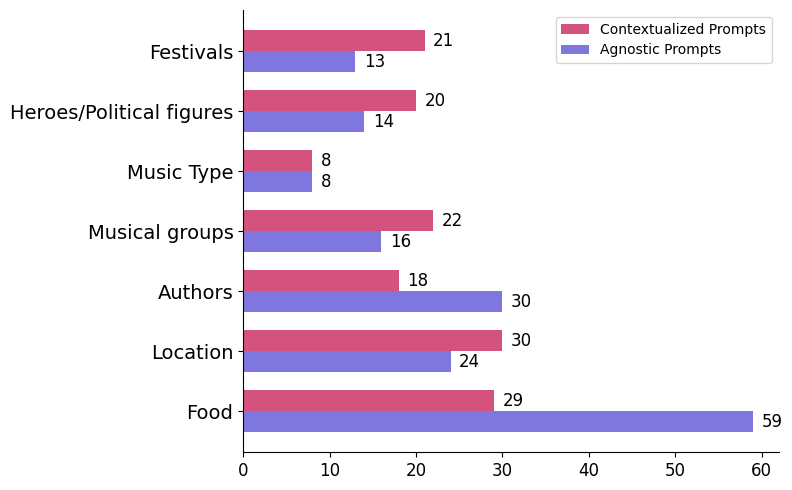

In [176]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# Load files
df_contextualized = pd.read_csv(
    "Prompts_cultural_final_creole.csv",
    header=None
)

df_agnostic = pd.read_csv(
    "Prompts_neutral_final_creole.csv",
    header=None
)

contextualized_text = df_contextualized.iloc[:, 0].astype(str)
agnostic_text = df_agnostic.iloc[:, 0].astype(str)

categories = [
    'Food',
    'Location',
    'Authors',
    'Musical groups',
    'Music Type',
    'Heroes/Political figures',
    'Festivals'
]

# Category names as they appear in the contextualized file
contextualized_patterns = {
    'Food': r'kategori\s+manje\s+epi',
    'Location': r'kategori\s+lye\s+epi',
    'Authors': r'kategori\s+otè\s+epi',
    'Musical groups': r'kategori\s+gwoup mikiz / chantè\s+epi',
    'Music Type': r'kategori\s+Mizik\s+epi',
    'Heroes/Political figures': r'kategori\s+ewo/ figi politik\s+epi',
    'Festivals': r'kategori\s+fèt\s+epi'
}

# Category names as they appear in the agnostic/neutral file
agnostic_patterns = {
    'Food': r'kategori\s+manje\s+epi',
    'Location': r'kategori\s+lye\s+epi',
    'Authors': r'kategori\s+otè\s+epi',
    'Musical groups': r'kategori\s+gwoup mikiz / chantè\s+epi',
    'Music Type': r'kategori\s+Mizik\s+epi',
    'Heroes/Political figures': r'kategori\s+Heroes/Political Figures\s+epi',
    'Festivals': r'kategori\s+fèt\s+epi'
}


# Calculate the values automatically
values_a = [
    contextualized_text.str.contains(
        pattern, case=False, regex=True
    ).sum()
    for category, pattern in contextualized_patterns.items()
]

values_b = [
    agnostic_text.str.contains(
        pattern, case=False, regex=True
    ).sum()
    for category, pattern in agnostic_patterns.items()
]


print("Contextualized:", values_a)
print("Agnostic:", values_b)


# plot
n = len(categories)
bar_height = 0.35
y = np.arange(n)

fig, ax = plt.subplots(figsize=(8, 5))

color_contextualized = '#D4537E'
color_agnostic = '#7F77DD'

for i, (val_a, val_b) in enumerate(zip(values_a, values_b)):

    ax.barh(
        y[i] + bar_height / 2,
        val_a,
        height=bar_height,
        color=color_contextualized
    )

    ax.barh(
        y[i] - bar_height / 2,
        val_b,
        height=bar_height,
        color=color_agnostic
    )



ax.set_yticks(y)
ax.set_yticklabels(categories)



for bars in ax.containers:
    for bar in bars:
        w = bar.get_width()

        ax.text(
            w + 1,
            bar.get_y() + bar.get_height() / 2,
            f'{w:.0f}',
            va='center',
            fontsize=12
        )


legend_elements = [
    Patch(
        facecolor=color_contextualized,
        label='Contextualized Prompts'
    ),
    Patch(
        facecolor=color_agnostic,
        label='Agnostic Prompts'
    )
]

ax.legend(handles=legend_elements)


# Style
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=14)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Mistral medium

Cultural Haitian Entity filling

Loading csv

In [ ]:
import pandas as pd

df_haitian_cultural = pd.read_csv("Cultural_creole_prompts_results.csv", header=None)
df_food = pd.read_csv("foods.csv", header=None)
df_food[0] = df_food[0].str.lower()
df_book = pd.read_csv("authors.csv", header=None)
df_loc = pd.read_csv("locations.csv", header=None)
df_music = pd.read_csv("Musical_groups.csv", header=None)
df_music_type = pd.read_csv("Music.csv", header=None)
df_heroes = pd.read_csv("Political_heros_figures.csv", header=None)
df_festival = pd.read_csv("Festivals.csv", header=None)

food = df_haitian_cultural.iloc[0:29]
food[0] = food[0].str.lower()
book = df_haitian_cultural.iloc[29:47]
location = df_haitian_cultural.iloc[47:77]
music_group= df_haitian_cultural.iloc[77:99]
music_type = df_haitian_cultural.iloc[99:107]
heroes = df_haitian_cultural.iloc[107:127]
festival = df_haitian_cultural.iloc[127:]

Haitian entity generated

In [ ]:
def commun_df(generated,list):
  commun = generated[generated[0].isin(list[0])]
  return commun

In [ ]:
commun_food = commun_df(food,df_food)
commun_book = commun_df(book,df_book)
commun_location = commun_df(location,df_loc)
commun_music_group = commun_df(music_group,df_music)
commun_music_type = commun_df(music_type,df_music_type)
commun_heroes = commun_df(heroes,df_heroes)
commun_festival = commun_df(festival,df_festival)
commun_total =  pd.concat([commun_food, commun_book, commun_location, commun_music_group, commun_music_type, commun_heroes, commun_festival], ignore_index=True)

Haitian Specificity

In [ ]:
def specificity(commun,total):
  return len(commun)/len(total)

In [ ]:
haitian_specificity = {}
haitian_specificity["cats"] = {}
haitian_specificity["cats"]["Food"] = specificity(commun_food,food)
haitian_specificity["cats"]["Authors"] = specificity(commun_book,book)
haitian_specificity["cats"]["Location"] = specificity(commun_location,location)
haitian_specificity["cats"]["Musical groups"] = specificity(commun_music_group,music_group)
haitian_specificity["cats"]["Music Type"] = specificity(commun_music_type,df_music_type)
haitian_specificity["cats"]["Heroes/Political figures"] = specificity(commun_heroes,heroes)
haitian_specificity["cats"]["Festivals"] = specificity(commun_festival,festival)
haitian_specificity["Total"] = specificity(commun_total,df_haitian_cultural)

In [ ]:
haitian_specificity

{'cats': {'Food': 0.6896551724137931,
  'Authors': 0.9444444444444444,
  'Location': 0.26666666666666666,
  'Musical groups': 1.0,
  'Music Type': 0.2,
  'Heroes/Political figures': 0.5,
  'Festivals': 0.42857142857142855},
 'Total': 0.6148648648648649}

In [ ]:
food

,0
0,pòm.
1,pikliz
2,pwa
3,diri ak pwa
4,pikliz
5,pikliz
6,pikliz
7,pikliz
8,pikliz
9,pikliz


Haitian Diversity

In [ ]:

def diversity(commun,total):
  values = commun[0]
  if len(values) == 0:
    return 0
  return values.nunique() / len(total)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
haitian_diversity = {}
haitian_diversity["cats"] = {}
haitian_diversity["cats"]["Food"] = diversity(commun_food,df_food)
haitian_diversity["cats"]["Authors"] = diversity(commun_book,df_book)
haitian_diversity["cats"]["Location"] = diversity(commun_location,df_loc)
haitian_diversity["cats"]["Musical groups"] = diversity(commun_music_group,df_music)
haitian_diversity["cats"]["Music Type"] = diversity(commun_music_type,df_music_type)
haitian_diversity["cats"]["Heroes/Political figures"] = diversity(commun_heroes,df_heroes)
haitian_diversity["cats"]["Festivals"] = diversity(commun_festival,df_festival)
haitian_diversity["Total"] = diversity(commun_total,df_haitian_cultural)

In [ ]:
haitian_diversity

{'cats': {'Food': 0.02617801047120419,
  'Authors': 0.01079913606911447,
  'Location': 0.0079155672823219,
  'Musical groups': 0.03,
  'Music Type': 0.12,
  'Heroes/Political figures': 0.04716981132075472,
  'Festivals': 0.024390243902439025},
 'Total': 0.20270270270270271}

 Cultural French Entity filling

In [ ]:
df_french_cultural = pd.read_csv("Cultural_french_prompts_results.csv", header=None)
df_food_french = pd.read_csv("french_foods.csv", header=None)
df_food_french[0] = df_food_french[0].str.lower()
df_location_french = pd.read_csv("french_locations.csv", header=None)
df_artists_french = pd.read_csv("french_artists.csv", header=None)

french_foods = df_french_cultural.iloc[0:29]
french_foods[0] = french_foods[0].str.lower()
french_location = df_french_cultural.iloc[29:59]
french_artists = df_french_cultural.iloc[59:]

/tmp/ipykernel_1641/2468956620.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  french_foods[0] = french_foods[0].str.lower()


French entity generated

In [ ]:
commun_french_food = commun_df(french_foods,df_food_french)
commun_french_location = commun_df(french_location,df_location_french) #a corriger frenc loc
commun_french_artists = commun_df(french_artists,df_artists_french)

French Specificity

In [ ]:
french_specificity = {}
french_specificity["cats"] = {}
french_specificity["cats"]["Food"] = specificity(commun_french_food,french_foods)
french_specificity["cats"]["Location"] = specificity(commun_french_location,french_location)
french_specificity["cats"]["Musical groups"] = specificity(commun_french_artists,french_artists)

In [ ]:
french_specificity

{'cats': {'Food': 0.9655172413793104,
  'Location': 0.9,
  'Musical groups': 0.9545454545454546}}

French Diversity

In [ ]:
french_diversity = {}
french_diversity["Food"] = diversity(commun_french_food,df_food_french)
french_diversity["Location"] = diversity(commun_french_location,df_location_french)
french_diversity["Musical groups"] = diversity(commun_french_artists,df_artists_french)

In [ ]:
french_diversity

{'Food': 0.10471204188481675,
 'Location': 0.007372654155495978,
 'Musical groups': 0.04}

Neutral Prompts -- Bias

In [ ]:
df_haitian_neutral = pd.read_csv("Neutral_creole_prompts_results.csv", header=None)

neutral_food = df_haitian_neutral.iloc[0:59]
neutral_food[0] = neutral_food[0].str.lower()
neutral_book = df_haitian_neutral.iloc[59:89]
neutral_location = df_haitian_neutral.iloc[89:113]
neutral_music_group = df_haitian_neutral.iloc[113:129]
neutral_music_type = df_haitian_neutral.iloc[129:137]
neutral_heroes = df_haitian_neutral.iloc[137:151]
neutral_festival = df_haitian_neutral.iloc[151:]

/tmp/ipykernel_1641/1249413390.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neutral_food[0] = neutral_food[0].str.lower()


In [ ]:
def uncommun_df(generated,list):
  uncommun = generated[~generated[0].isin(list[0])]

In [ ]:
uncommun_food = neutral_food[~neutral_food[0].isin(df_food[0])]
uncommun_book = neutral_book[~neutral_book[0].isin(df_book[0])]
uncommun_location = neutral_location[~neutral_location[0].isin(df_loc[0])]
uncommun_music_group = neutral_music_group[~neutral_music_group[0].isin(df_music[0])]
uncommun_music_type = neutral_music_type[~neutral_music_type[0].isin(df_music_type[0])]
uncommun_heroes = neutral_heroes[~neutral_heroes[0].isin(df_heroes[0])]
uncommun_festival = neutral_festival[~neutral_festival[0].isin(df_festival[0])]
uncommun_total =  pd.concat([uncommun_food, uncommun_book, uncommun_location, uncommun_music_group, uncommun_music_type, uncommun_heroes, uncommun_festival], ignore_index=True)

In [ ]:
def bias(ncommun,total):
  return len(ncommun)/len(total)

In [ ]:

neutral_food[~neutral_food[0].isin(df_food[0])]

,0
0,pwa
1,pwa
2,pwa
4,pwa kongo
5,pwa
6,pwa
7,pwa
9,pwa
10,pwa
11,gato


Haitian bias

In [ ]:
ht_bias = {}
ht_bias["cats"] = {}
ht_bias["cats"]["Food"] = bias(uncommun_food,neutral_food)
ht_bias["cats"]["Authors"] = bias(uncommun_book,neutral_book)
ht_bias["cats"]["Location"] = bias(uncommun_location,neutral_location)
ht_bias["cats"]["Musical groups"] = bias(uncommun_music_group,neutral_music_group)
ht_bias["cats"]["Music Type"] = bias(uncommun_music_type,neutral_music_type)
ht_bias["cats"]["Heroes/Political figures"] = bias(uncommun_heroes,neutral_heroes)
ht_bias["cats"]["Festivals"] = bias(uncommun_festival,neutral_festival)
ht_bias["Total"] = bias(uncommun_total,df_haitian_neutral)

In [ ]:
ht_bias

{'cats': {'Food': 0.847457627118644,
  'Authors': 0.7333333333333333,
  'Location': 0.9166666666666666,
  'Musical groups': 0.0,
  'Music Type': 0.0,
  'Heroes/Political figures': 0.35714285714285715,
  'Festivals': 0.9230769230769231},
 'Total': 0.676829268292683}

French bias

In [ ]:
df_french_neutral = pd.read_csv("Neutral_french_prompts_results.csv", header=None)

neutral_french_food = df_french_neutral.iloc[0:59]
neutral_french_food[0] = neutral_french_food[0].str.lower()
neutral_french_location = df_french_neutral.iloc[89:113]
neutral_french_music_group = df_french_neutral.iloc[113:129]

/tmp/ipykernel_1641/490751693.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neutral_french_food[0] = neutral_french_food[0].str.lower()


In [ ]:
uncommun_french_food = neutral_french_food[~neutral_french_food[0].isin(df_food_french[0])]
uncommun_french_location = neutral_french_location[~neutral_french_location[0].isin(df_location_french[0])]#a corriger frenc lo
uncommun_french_music_group = neutral_french_music_group[~neutral_french_music_group[0].isin(df_artists_french[0])]

In [ ]:
bias_french = {}
bias_french["Food"] = bias(uncommun_french_food,neutral_french_food)
bias_french["Location"] = bias(uncommun_french_location,neutral_french_location)
bias_french["Musical groups"] = bias(uncommun_french_music_group,neutral_french_music_group)

In [ ]:
bias_french

{'Food': 0.8305084745762712, 'Location': 0.0, 'Musical groups': 0.25}

Haitian variation

In [ ]:
df_ht_1 = pd.read_csv("Cultural_creole_prompts_results.csv", header=None)
df_ht_2 = pd.read_csv("Cultural_creole_prompts_results2.csv", header=None)
df_ht_3 = pd.read_csv("Cultural_creole_prompts_results3.csv", header=None)
df_ht_4 = pd.read_csv("Cultural_creole_prompts_results4.csv", header=None)
df_ht_5 = pd.read_csv("Cultural_creole_prompts_results5.csv", header=None)
df_ht_6 = pd.read_csv("Cultural_creole_prompts_results6.csv", header=None)
df_ht_7 = pd.read_csv("Cultural_creole_prompts_results7.csv", header=None)
df_ht_8 = pd.read_csv("Cultural_creole_prompts_results8.csv", header=None)
df_ht_9 = pd.read_csv("Cultural_creole_prompts_results9.csv", header=None)
df_ht_10 = pd.read_csv("Cultural_Creole_Prompts_Results10.csv", header=None)

In [ ]:
df_ht_total = pd.concat([df_ht_1,df_ht_2,df_ht_3,df_ht_4,df_ht_5,df_ht_6,df_ht_7,df_ht_8,df_ht_9,df_ht_10], axis=1)

In [ ]:
df_ht_unique = df_ht_total.apply(lambda row: row.nunique()/10, axis=1)

In [ ]:
variation_ht_food = df_ht_unique.iloc[0:29]
variation_ht_book = df_ht_unique.iloc[29:46]
variation_ht_location = df_ht_unique.iloc[46:77]
variation_ht_music_group = df_ht_unique.iloc[77:99]
variation_ht_music_type = df_ht_unique.iloc[99:107]
variation_ht_heroes = df_ht_unique.iloc[107:127]
variation_ht_festival = df_ht_unique.iloc[127:]

In [ ]:
def variation(unique):
  return unique.mean()

In [ ]:
variation_ht = {}
variation_ht["cats"] = {}
variation_ht["cats"]["Food"] = variation(variation_ht_food)
variation_ht["cats"]["Authors"] = variation(variation_ht_book)
variation_ht["cats"]["Location"] = variation(variation_ht_location)
variation_ht["cats"]["Musical groups"] = variation(variation_ht_music_group)
variation_ht["cats"]["Music Type"] = variation(variation_ht_music_type)
variation_ht["cats"]["Heroes/Political figures"] = variation(variation_ht_heroes)
variation_ht["cats"]["Festivals"] = variation(variation_ht_festival)
variation_ht["Total"] = variation(df_ht_unique)

In [ ]:
variation_ht

{'cats': {'Food': np.float64(0.16551724137931037),
  'Authors': np.float64(0.15882352941176472),
  'Location': np.float64(0.15161290322580637),
  'Musical groups': np.float64(0.14090909090909096),
  'Music Type': np.float64(0.1875),
  'Heroes/Political figures': np.float64(0.14000000000000004),
  'Festivals': np.float64(0.19523809523809527)},
 'Total': np.float64(0.16013513513513516)}

French variation

In [ ]:
df_fr_1 = pd.read_csv("Cultural_french_prompts_results.csv", header=None)
df_fr_2 = pd.read_csv("Cultural_french_prompts_results2.csv", header=None)
df_fr_3 = pd.read_csv("Cultural_french_prompts_results3.csv", header=None)
df_fr_4 = pd.read_csv("Cultural_french_prompts_results4.csv", header=None)
df_fr_5 = pd.read_csv("Cultural_french_prompts_results5.csv", header=None)
df_fr_6 = pd.read_csv("Cultural_french_prompts_results6.csv", header=None)
df_fr_7 = pd.read_csv("Cultural_french_prompts_results7.csv", header=None)
df_fr_8 = pd.read_csv("Cultural_french_prompts_results8.csv", header=None)
df_fr_9 = pd.read_csv("Cultural_french_prompts_results9.csv", header=None)
df_fr_10 = pd.read_csv("Cultural_french_prompts_results10.csv", header=None)

In [ ]:
df_fr_total = pd.concat([df_fr_1,df_fr_2,df_fr_3,df_fr_4,df_fr_5,df_fr_6,df_fr_7,df_fr_8,df_fr_9,df_fr_10], axis=1)

In [ ]:
df_fr_unique = df_fr_total.apply(lambda row: row.nunique()/10, axis=1)

In [ ]:
variation_fr_food = df_fr_unique.iloc[0:29]
variation_fr_location = df_fr_unique.iloc[29:59]
variation_fr_artists = df_fr_unique.iloc[59:]

In [ ]:
variation_fr = {}
variation_fr["Food"] = variation(variation_fr_food)
variation_fr["Location"] = variation(variation_fr_location)
variation_fr["Musical groups"] = variation(variation_fr_artists)

In [ ]:
variation_fr

{'Food': np.float64(0.11379310344827588),
 'Location': np.float64(0.13000000000000003),
 'Musical groups': np.float64(0.11818181818181821)}

Large Model

Cultural Haitian Entity filling

In [ ]:
df_haitian_cultural_large = pd.read_csv("Cultural_creole_prompts_results_large.csv", header=None)

food_large = df_haitian_cultural_large.iloc[0:29]
food_large[0].str.lower()
book_large = df_haitian_cultural_large.iloc[29:47]
location_large = df_haitian_cultural_large.iloc[47:77]
music_group_large = df_haitian_cultural_large.iloc[77:99]
music_type_large = df_haitian_cultural_large.iloc[99:107]
heroes_large = df_haitian_cultural_large.iloc[107:127]
festival_large = df_haitian_cultural_large.iloc[127:]

In [ ]:
commun_food_large = commun_df(food_large,df_food)
commun_book_large = commun_df(book_large,df_book)
commun_location_large = commun_df(location_large,df_loc)
commun_music_group_large = commun_df(music_group_large,df_music)
commun_music_type_large = commun_df(music_type_large,df_music_type)
commun_heroes_large = commun_df(heroes_large,df_heroes)
commun_festival_large = commun_df(festival_large,df_festival)
commun_total_large =  pd.concat([commun_food_large, commun_book_large, commun_location_large, commun_music_group_large, commun_music_type_large, commun_heroes_large, commun_festival_large], ignore_index=True)

In [ ]:
haitian_specificity_large = {}
haitian_specificity_large["cats"] = {}
haitian_specificity_large["cats"]["Food"] = specificity(commun_food_large,food_large)
haitian_specificity_large["cats"]["Authors"] = specificity(commun_book_large,book_large)
haitian_specificity_large["cats"]["Location"] = specificity(commun_location_large,location_large)
haitian_specificity_large["cats"]["Musical groups"] = specificity(commun_music_group_large,music_group_large)
haitian_specificity_large["cats"]["Music Type"] = specificity(commun_music_type_large,music_type_large)
haitian_specificity_large["cats"]["Heroes/Political figures"] = specificity(commun_heroes_large,heroes_large)
haitian_specificity_large["cats"]["Festivals"] = specificity(commun_festival_large,festival_large)
haitian_specificity_large["Total"] = specificity(commun_total_large,df_haitian_cultural_large)

In [ ]:
haitian_specificity_large

{'cats': {'Food': 0.10344827586206896,
  'Authors': 0.5,
  'Location': 0.1,
  'Musical groups': 0.5909090909090909,
  'Music Type': 0.625,
  'Heroes/Political figures': 0.05,
  'Festivals': 0.2857142857142857},
 'Total': 0.2702702702702703}

In [ ]:
haitian_diversity_large = {}
haitian_diversity_large["cats"] = {}
haitian_diversity_large["cats"]["Food"] = diversity(commun_food_large,df_food)
haitian_diversity_large["cats"]["Authors"] = diversity(commun_book_large,df_book)
haitian_diversity_large["cats"]["Location"] = diversity(commun_location_large,df_loc)
haitian_diversity_large["cats"]["Musical groups"] = diversity(commun_music_group_large,df_music)
haitian_diversity_large["cats"]["Music Type"] = diversity(commun_music_type_large,df_music_type)
haitian_diversity_large["cats"]["Heroes/Political figures"] = diversity(commun_heroes_large,df_heroes)
haitian_diversity_large["cats"]["Festivals"] = diversity(commun_festival_large,df_festival)
haitian_diversity_large["Total"] = diversity(commun_total_large,df_haitian_cultural_large)

In [ ]:

haitian_diversity_large

{'cats': {'Food': 0.010471204188481676,
  'Authors': 0.0064794816414686825,
  'Location': 0.005277044854881266,
  'Musical groups': 0.025,
  'Music Type': 0.08,
  'Heroes/Political figures': 0.009433962264150943,
  'Festivals': 0.024390243902439025},
 'Total': 0.12162162162162163}

French Entity Filling

In [ ]:
df_french_cultural_large = pd.read_csv("Cultural_french_prompts_results_large.csv", header=None)

french_food_large = df_french_cultural_large.iloc[0:29]
french_food_large[0].str.lower
french_location_large = df_french_cultural_large.iloc[29:59]
french_artists_large = df_french_cultural_large.iloc[59:]


In [ ]:
commun_french_food_large = commun_df(french_food_large,df_food_french)
commun_french_location_large = commun_df(french_location_large,df_location_french)
commun_french_artists_large = commun_df(french_artists_large,df_artists_french)

In [ ]:
french_specificity_large = {}
french_specificity_large["Food"] = specificity(commun_french_food_large,french_food_large)
french_specificity_large["Location"] = specificity(commun_french_location_large,french_location_large)
french_specificity_large["Musical groups"] = specificity(commun_french_artists_large,french_artists_large)

In [ ]:
french_specificity_large

{'Food': 0.27586206896551724,
 'Location': 0.7,
 'Musical groups': 0.9090909090909091}

In [ ]:
french_diversity_large = {}
french_diversity_large["Food"] = diversity(commun_french_food_large,df_food_french)
french_diversity_large["Location"] = diversity(commun_french_location_large,df_location_french)
french_diversity_large["Musical groups"] = diversity(commun_french_artists_large,df_artists_french)

In [ ]:
french_diversity_large

{'Food': 0.02617801047120419,
 'Location': 0.005361930294906166,
 'Musical groups': 0.02}

Neutral Prompts Large

In [ ]:
df_neutral_large = pd.read_csv("Neutral_creole_prompts_results_large.csv", header=None)

neutral_food_large = df_neutral_large.iloc[0:59]
neutral_food_large[0].str.lower
neutral_book_large = df_neutral_large.iloc[59:89]
neutral_location_large = df_neutral_large.iloc[89:113]
neutral_music_group_large = df_neutral_large.iloc[113:129]
neutral_music_type_large = df_neutral_large.iloc[129:137]
neutral_heroes_large = df_neutral_large.iloc[137:151]
neutral_festival_large = df_neutral_large.iloc[151:]

In [ ]:
uncommun_food_large = neutral_food_large[~neutral_food_large[0].isin(df_food[0])]
uncommun_book_large = neutral_book_large[~neutral_book_large[0].isin(df_book[0])]
uncommun_location_large = neutral_location_large[~neutral_location_large[0].isin(df_loc[0])]
uncommun_music_group_large = neutral_music_group_large[~neutral_music_group_large[0].isin(df_music[0])]
uncommun_music_type_large = neutral_music_type_large[~neutral_music_type_large[0].isin(df_music_type[0])]
uncommun_heroes_large = neutral_heroes_large[~neutral_heroes_large[0].isin(df_heroes[0])]
uncommun_festival_large = neutral_festival_large[~neutral_festival_large[0].isin(df_festival[0])]
uncommun_total_large =  pd.concat([uncommun_food_large, uncommun_book_large, uncommun_location_large, uncommun_music_group_large, uncommun_music_type_large, uncommun_heroes_large, uncommun_festival_large], ignore_index=True)

In [ ]:
ht_large_bias = {}
ht_large_bias["cats"] = {}
ht_large_bias["cats"]["Food"] = bias(uncommun_food_large,neutral_food_large)
ht_large_bias["cats"]["Authors"] = bias(uncommun_book_large,neutral_book_large)
ht_large_bias["cats"]["Location"] = bias(uncommun_location_large,neutral_location_large)
ht_large_bias["cats"]["Musical groups"] = bias(uncommun_music_group_large,neutral_music_group_large)
ht_large_bias["cats"]["Music Type"] = bias(uncommun_music_type_large,neutral_music_type_large)
ht_large_bias["cats"]["Heroes/Political figures"] = bias(uncommun_heroes_large,neutral_heroes_large)
ht_large_bias["cats"]["Festivals"] = bias(uncommun_festival_large,neutral_festival_large)
ht_large_bias["Total"] = bias(uncommun_total_large,df_haitian_neutral)

In [ ]:
ht_large_bias

{'cats': {'Food': 1.0,
  'Authors': 1.0,
  'Location': 0.9583333333333334,
  'Musical groups': 0.9375,
  'Music Type': 0.75,
  'Heroes/Political figures': 1.0,
  'Festivals': 0.7692307692307693},
 'Total': 0.9573170731707317}

French bias

In [ ]:
df_french_neutral_large = pd.read_csv("Neutral_french_prompts_results_large.csv", header=None)

neutral_french_food_large = df_french_neutral_large.iloc[0:59]
neutral_french_food_large[0].str.lower
neutral_french_location_large = df_french_neutral_large.iloc[89:113]
neutral_french_music_group_large = df_french_neutral_large.iloc[113:129]

In [ ]:
uncommun_french_food_large = neutral_french_food_large[~neutral_french_food_large[0].isin(df_food_french[0])]
uncommun_french_location_large = neutral_french_location_large[~neutral_french_location_large[0].isin(df_location_french[0])]
uncommun_french_music_group = neutral_french_music_group_large[~neutral_french_music_group_large[0].isin(df_artists_french[0])]

In [ ]:
bias_french_large = {}
bias_french_large["Food"] = bias(uncommun_french_food_large,neutral_french_food_large)
bias_french_large["Location"] = bias(uncommun_french_location_large,neutral_french_location_large)
bias_french_large["Musical groups"] =bias(uncommun_french_music_group,neutral_french_music_group_large)

In [ ]:
bias_french_large

{'Food': 0.9152542372881356, 'Location': 0.125, 'Musical groups': 0.625}

Variation Large

In [ ]:
df_htl_1 = pd.read_csv("Cultural_creole_prompts_results_large.csv", header=None)
df_htl_2 = pd.read_csv("Cultural_Creole_Prompts_Results_large2.csv", header=None)
df_htl_3 = pd.read_csv("Cultural_Creole_Prompts_Results_large3.csv", header=None)
df_htl_4 = pd.read_csv("Cultural_Creole_Prompts_Results_large4.csv", header=None)
df_htl_5 = pd.read_csv("Cultural_Creole_Prompts_Results_large5.csv", header=None)
df_htl_6 = pd.read_csv("Cultural_Creole_Prompts_Results_large6.csv", header=None)
df_htl_7 = pd.read_csv("Cultural_Creole_Prompts_Results_large7.csv", header=None)
df_htl_8 = pd.read_csv("Cultural_Creole_Prompts_Results_large8.csv", header=None)
df_htl_9 = pd.read_csv("Cultural_Creole_Prompts_Results_large9.csv", header=None)
df_htl_10 = pd.read_csv("Cultural_Creole_Prompts_Results_large1.csv", header=None)

In [ ]:
df_htl_total = pd.concat([df_htl_1,df_htl_2,df_htl_3,df_htl_4,df_htl_5,df_htl_6,df_htl_7,df_htl_8,df_htl_9,df_htl_10], axis=1)

In [ ]:
df_htl_unique = df_htl_total.apply(lambda row: row.nunique()/10, axis=1)

In [ ]:
variation_htl_food = df_htl_unique.iloc[0:29]
variation_htl_book = df_htl_unique.iloc[29:47]
variation_htl_location = df_htl_unique.iloc[47:77]
variation_htl_music_group = df_htl_unique.iloc[77:99]
variation_htl_music_type = df_htl_unique.iloc[99:107]
variation_htl_heroes = df_htl_unique.iloc[107:127]
variation_htl_festival = df_htl_unique.iloc[127:]

In [ ]:
variation_htl = {}
variation_htl["cats"] = {}
variation_htl["cats"]["Food"] = variation(variation_htl_food)
variation_htl["cats"]["Authors"] = variation(variation_htl_book)
variation_htl["cats"]["Location"] = variation(variation_htl_location)
variation_htl["cats"]["Musical groups"] = variation(variation_htl_music_group)
variation_htl["cats"]["Music Type"] = variation(variation_htl_music_type)
variation_htl["cats"]["Heroes/Political figures"] = variation(variation_htl_heroes)
variation_htl["cats"]["Festivals"] = variation(variation_htl_festival)
variation_htl["Total"] = variation(df_htl_unique)

In [ ]:
variation_htl

{'cats': {'Food': np.float64(0.19655172413793104),
  'Authors': np.float64(0.18333333333333335),
  'Location': np.float64(0.19999999999999993),
  'Musical groups': np.float64(0.1454545454545455),
  'Music Type': np.float64(0.17500000000000002),
  'Heroes/Political figures': np.float64(0.17),
  'Festivals': np.float64(0.1523809523809524)},
 'Total': np.float64(0.17702702702702705)}

French

In [ ]:
df_frl_1 = pd.read_csv("Cultural_french_prompts_results_large.csv", header=None)
df_frl_2 = pd.read_csv("Cultural_French_Prompts_Results_large1.csv", header=None)
df_frl_3 = pd.read_csv("Cultural_French_Prompts_Results_large2.csv", header=None)
df_frl_4 = pd.read_csv("Cultural_French_Prompts_Results_large3.csv", header=None)
df_frl_5 = pd.read_csv("Cultural_French_Prompts_Results_large4.csv", header=None)
df_frl_6 = pd.read_csv("Cultural_French_Prompts_Results_large5.csv", header=None)
df_frl_7 = pd.read_csv("Cultural_french_prompts_results_large6.csv", header=None)
df_frl_8 = pd.read_csv("Cultural_French_Prompts_Results_large7.csv", header=None)
df_frl_9 = pd.read_csv("Cultural_French_Prompts_Results_large8.csv", header=None)
df_frl_10 = pd.read_csv("Cultural_French_Prompts_Results_large9.csv", header=None)

In [ ]:
df_frl_total = pd.concat([df_frl_1,df_frl_2,df_frl_3,df_frl_4,df_frl_5,df_frl_6,df_frl_7,df_frl_8,df_frl_9,df_frl_10], axis=1)

In [ ]:
df_frl_unique = df_frl_total.apply(lambda row: row.nunique()/10, axis=1)

In [ ]:
variation_frl_food = df_frl_unique.iloc[0:29]
variation_frl_location = df_frl_unique.iloc[29:59]
variation_frl_artists = df_frl_unique.iloc[59:]

In [ ]:
variation_frl = {}
variation_frl["food"] = variation(variation_frl_food)
variation_frl["location"] = variation(variation_frl_location)
variation_frl["Musical groups"] = variation(variation_frl_artists)

In [ ]:
variation_frl

{'food': np.float64(0.13793103448275862),
 'location': np.float64(0.14666666666666664),
 'Musical groups': np.float64(0.11818181818181821)}

In [ ]:
data= {'specificity': haitian_specificity ,
        'diversity': haitian_diversity ,
             'bias': ht_bias ,
             'variation': variation_ht }

In [ ]:
data


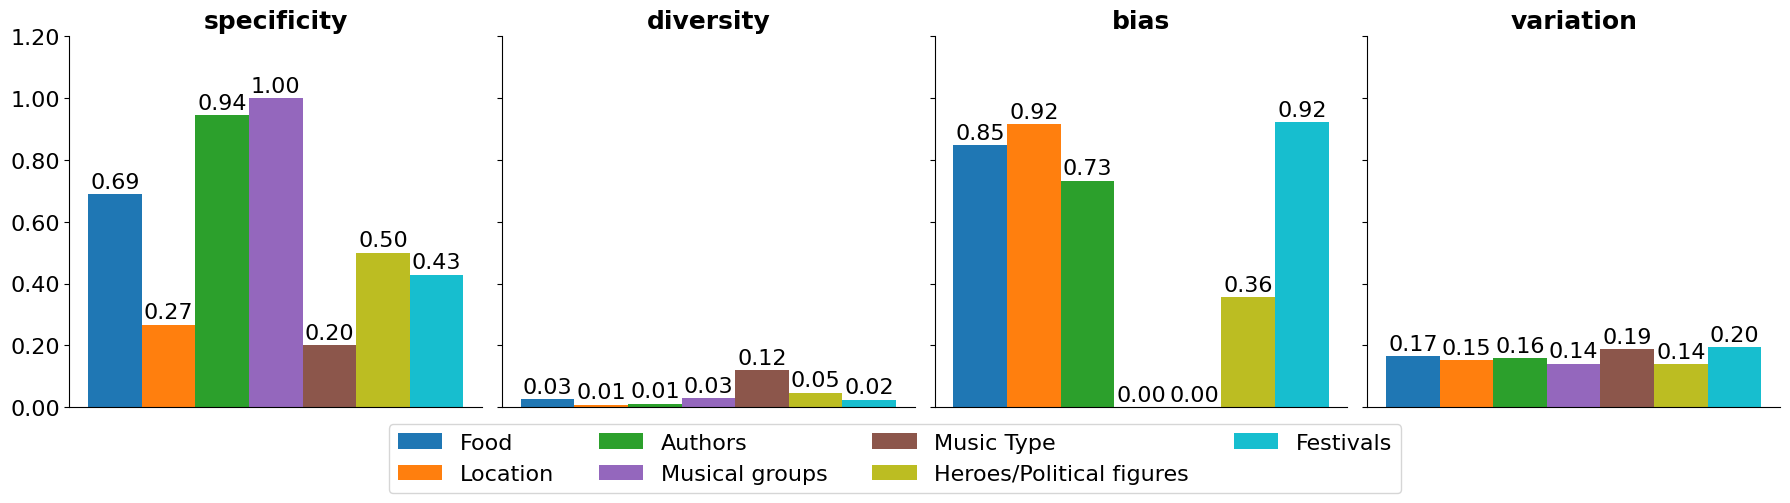

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

cate = ['Food', 'Location', 'Authors',
        'Musical groups', 'Music Type', 'Name',
        'Heroes/Political figures', 'Festivals']

category_order = ['Food', 'Location', 'Authors',
                  'Musical groups', 'Music Type',
                  'Heroes/Political figures', 'Festivals']


colors = plt.cm.tab10(np.linspace(0, 1, len(cate)))
color_map = dict(zip(cate, colors))

total_color = '#7F77DD'

fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)

x_cats  = np.arange(len(category_order))
x_total = 9

all_vals = [v for d in data.values()
              for v in [*d['cats'].values()]]
offset = max(all_vals) * 0.02
y_max = max(all_vals) * 1.2

for ax, (name, d) in zip(axes, data.items()):

    vals = [d['cats'][cat] for cat in category_order]

    for i, cat in enumerate(category_order):
        ax.bar(x_cats[i], vals[i],
               color=color_map[cat],
               width=1.0)
    ax.set_xticks([])

    # Y axis
    ax.set_ylim(0, y_max)
    ax.tick_params(axis='y', labelsize=16)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{x:.2f}')
    )

    for xi, vi in zip([*x_cats, x_total], [*vals]):
        ax.text(xi, vi + offset, f'{vi:.2f}',
                ha='center', fontsize=16)

    ax.set_title(name, fontsize=18, fontweight='bold')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

legend_elements = [
    Patch(facecolor=color_map[cat], label=cat)
    for cat in category_order
]
fig.legend(handles=legend_elements,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.02),
           ncol=4,
           fontsize=16
           )

plt.tight_layout(rect=[0, 0.12, 1, 1])

plt.show()

In [ ]:
data_large = {'specificity': haitian_specificity_large ,
        'diversity': haitian_diversity_large ,
             'bias': ht_large_bias ,
             'variation': variation_htl }

In [ ]:
data_large

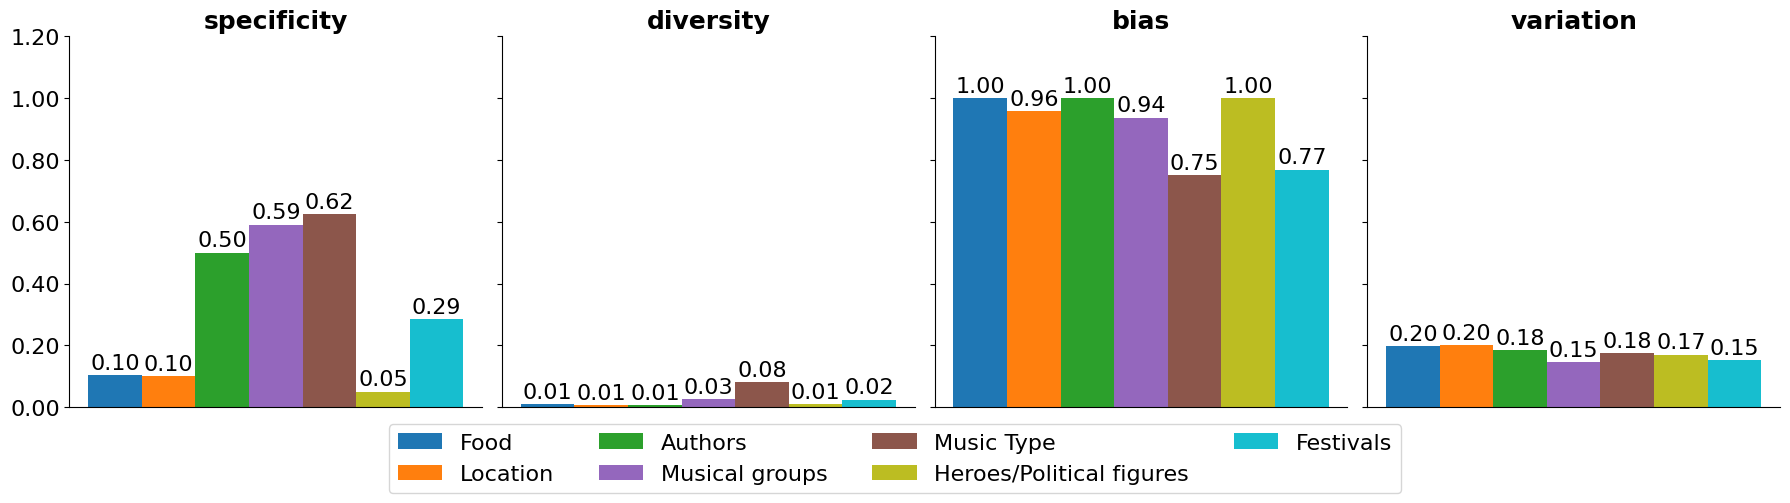

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

cate = ['Food', 'Location', 'Authors',
        'Musical groups', 'Music Type', 'Name',
        'Heroes/Political figures', 'Festivals']

category_order = ['Food', 'Location', 'Authors',
                  'Musical groups', 'Music Type',
                  'Heroes/Political figures', 'Festivals']

colors = plt.cm.tab10(np.linspace(0, 1, len(cate)))
color_map = dict(zip(cate, colors))

total_color = '#7F77DD'

fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)

x_cats  = np.arange(len(category_order))
x_total = 9


all_vals = [v for d in data_large.values()
              for v in [*d['cats'].values()]]
offset = max(all_vals) * 0.02
y_max = max(all_vals) * 1.2

for ax, (name, d) in zip(axes, data_large.items()):

    vals = [d['cats'][cat] for cat in category_order]

    for i, cat in enumerate(category_order):
        ax.bar(x_cats[i], vals[i],
               color=color_map[cat],
               width=1.0)




    ax.set_xticks([])

    ax.set_ylim(0, y_max)
    ax.tick_params(axis='y', labelsize=16)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{x:.2f}')
    )


    for xi, vi in zip([*x_cats, x_total], [*vals]):
        ax.text(xi, vi + offset, f'{vi:.2f}',
                ha='center', fontsize=16)

    ax.set_title(name, fontsize=18, fontweight='bold')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


legend_elements = [
    Patch(facecolor=color_map[cat], label=cat)
    for cat in category_order
]

fig.legend(handles=legend_elements,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.02),
           ncol=4,
           fontsize=16)
plt.tight_layout(rect=[0, 0.12, 1, 1])

plt.show()

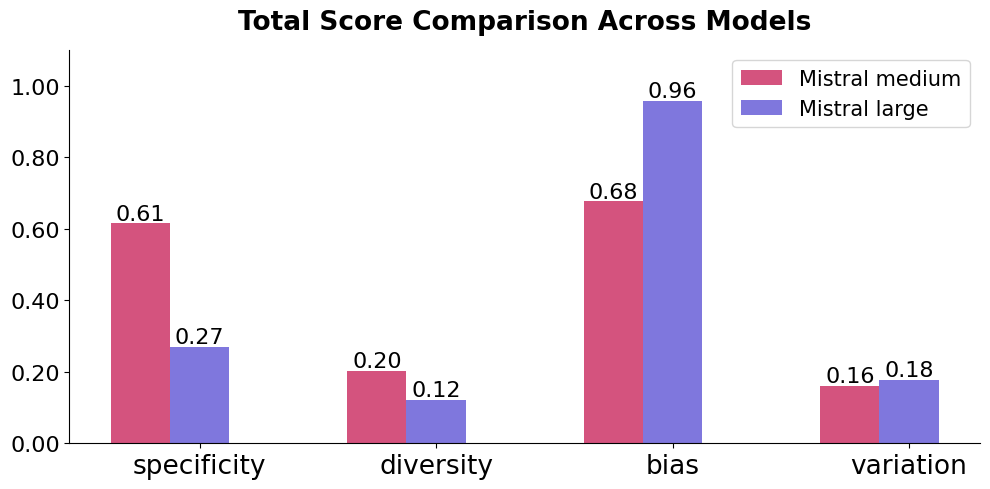

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


models = {
    'Mistral medium': data,
    'Mistral large': data_large
}

colors = ['#D4537E', '#7F77DD']

metrics = list(next(iter(models.values())).keys())

x = np.arange(len(metrics))
bar_width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))

for i, (model_name, model_data) in enumerate(models.items()):

    totals = [model_data[m]['Total'] for m in metrics]

    ax.bar(x + (i - 1) * bar_width,
           totals,
           width=bar_width,
           label=model_name,
           color=colors[i])

    for xi, vi in zip(x + (i - 1) * bar_width, totals):
        ax.text(xi, vi + 0.01,
                f'{vi:.2f}',
                ha='center',
                fontsize=16)


ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=19)

ax.tick_params(axis='y', labelsize=16)

ax.set_ylim(0, 1.1)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f'{v:.2f}')
)


ax.legend(fontsize=15)
ax.set_title("Total Score Comparison Across Models",
             fontsize=19, fontweight='bold', pad=15)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

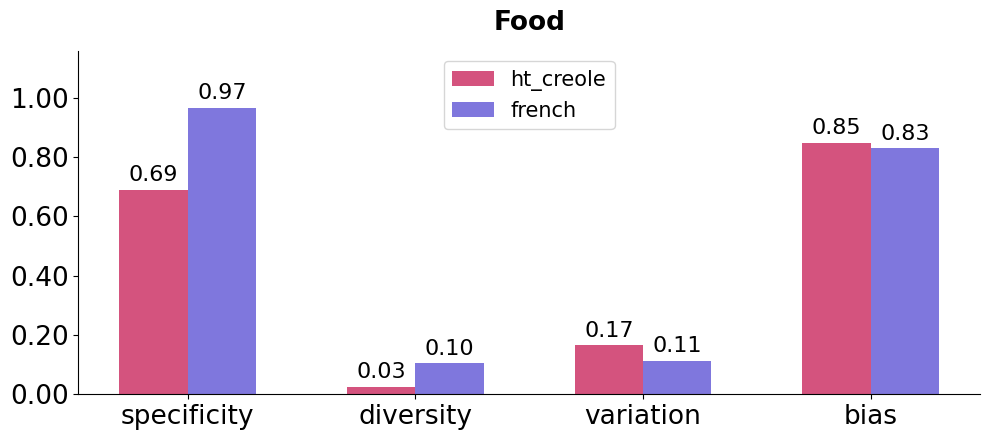

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

series_colors = {
    'ht_creole': '#D4537E',
    'french': '#7F77DD'
}

data_french = {
    'specificity': {
        'ht_creole': haitian_specificity["cats"]['Food'],
        'french': french_specificity["cats"]['Food']
    },
    'diversity': {
        'ht_creole': haitian_diversity["cats"]['Food'],
        'french': french_diversity['Food']
    },
    'variation': {
        'ht_creole': variation_ht["cats"]['Food'],
        'french': variation_fr['Food']
    },
    'bias': {
        'ht_creole': ht_bias["cats"]['Food'],
        'french': bias_french['Food']
    }
}

fig, ax = plt.subplots(figsize=(10, 4.5))

metrics = list(data_french.keys())
vals_ht = [d['ht_creole'] for d in data_french.values()]
vals_fr = [d['french'] for d in data_french.values()]

bar_width = 0.3
x = np.arange(len(metrics))

offset = max([*vals_ht, *vals_fr]) * 0.03
y_max = max([*vals_ht, *vals_fr]) * 1.2

#Bars
ax.bar(x - bar_width/2, vals_ht,
       width=bar_width,
       color=series_colors['ht_creole'],
       label='ht_creole')

ax.bar(x + bar_width/2, vals_fr,
       width=bar_width,
       color=series_colors['french'],
       label='french')

#Value labels
for xi, vi in zip(x - bar_width/2, vals_ht):
    ax.text(xi, vi + offset, f'{vi:.2f}',
            ha='center', fontsize=16)

for xi, vi in zip(x + bar_width/2, vals_fr):
    ax.text(xi, vi + offset, f'{vi:.2f}',
            ha='center', fontsize=16)


ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=19)

ax.tick_params(axis='y', labelsize=19)

ax.set_ylim(0, y_max)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f'{v:.2f}')
)


ax.legend(fontsize=15)


ax.set_title("Food", fontsize=19, fontweight='bold', pad=15)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
data_french

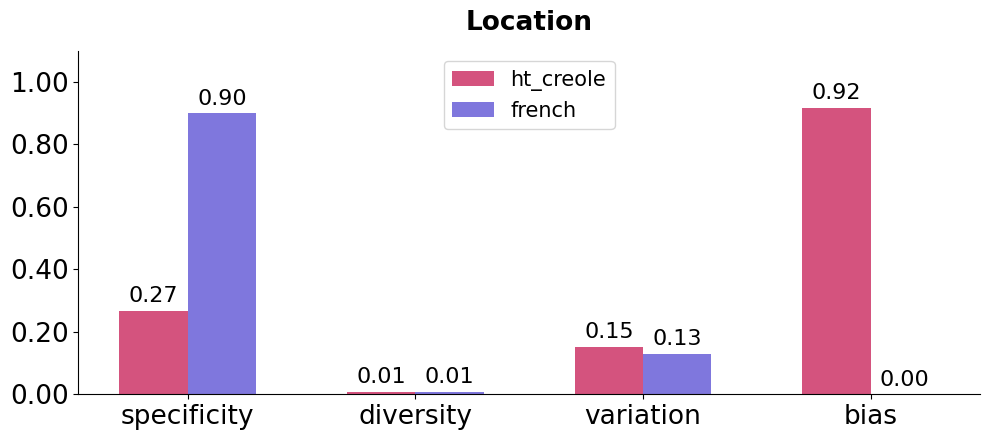

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

data_french =  {'specificity': { 'ht_creole':haitian_specificity["cats"]['Location'], 'french':french_specificity["cats"]['Location'] } ,
        'diversity': { 'ht_creole':haitian_diversity["cats"]['Location'], 'french':french_diversity['Location'] } ,
                'variation': { 'ht_creole':variation_ht["cats"]['Location'], 'french':variation_fr['Location'] } ,
                'bias': { 'ht_creole':ht_bias["cats"]['Location'], 'french':bias_french['Location'] } }

fig, ax = plt.subplots(figsize=(10, 4.5))

metrics = list(data_french.keys())
vals_ht = [d['ht_creole'] for d in data_french.values()]
vals_fr = [d['french'] for d in data_french.values()]

bar_width = 0.3
x = np.arange(len(metrics))

offset = max([*vals_ht, *vals_fr]) * 0.03
y_max = max([*vals_ht, *vals_fr]) * 1.2


ax.bar(x - bar_width/2, vals_ht,
       width=bar_width,
       color=series_colors['ht_creole'],
       label='ht_creole')

ax.bar(x + bar_width/2, vals_fr,
       width=bar_width,
       color=series_colors['french'],
       label='french')

for xi, vi in zip(x - bar_width/2, vals_ht):
    ax.text(xi, vi + offset, f'{vi:.2f}',
            ha='center', fontsize=16)

for xi, vi in zip(x + bar_width/2, vals_fr):
    ax.text(xi, vi + offset, f'{vi:.2f}',
            ha='center', fontsize=16)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=19)

ax.tick_params(axis='y', labelsize=19)

ax.set_ylim(0, y_max)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f'{v:.2f}')
)

ax.legend(fontsize=15)

ax.set_title("Location", fontsize=19, fontweight='bold', pad=15)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

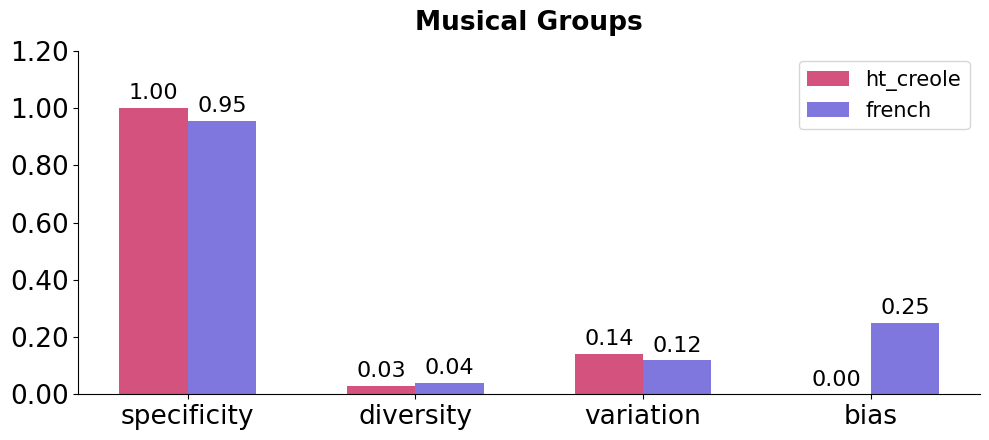

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

data_french =  {'specificity': { 'ht_creole':haitian_specificity["cats"]['Musical groups'], 'french':french_specificity["cats"]['Musical groups'] } ,
        'diversity': { 'ht_creole':haitian_diversity["cats"]['Musical groups'], 'french':french_diversity['Musical groups'] } ,
                'variation': { 'ht_creole':variation_ht["cats"]['Musical groups'], 'french':variation_fr['Musical groups'] } ,
                'bias': { 'ht_creole':ht_bias["cats"]['Musical groups'], 'french':bias_french['Musical groups'] } }

fig, ax = plt.subplots(figsize=(10, 4.5))
metrics = list(data_french.keys())
vals_ht = [d['ht_creole'] for d in data_french.values()]
vals_fr = [d['french'] for d in data_french.values()]

bar_width = 0.3
x = np.arange(len(metrics))

offset = max([*vals_ht, *vals_fr]) * 0.03
y_max = max([*vals_ht, *vals_fr]) * 1.2


ax.bar(x - bar_width/2, vals_ht,
       width=bar_width,
       color=series_colors['ht_creole'],
       label='ht_creole')

ax.bar(x + bar_width/2, vals_fr,
       width=bar_width,
       color=series_colors['french'],
       label='french')

for xi, vi in zip(x - bar_width/2, vals_ht):
    ax.text(xi, vi + offset, f'{vi:.2f}',
            ha='center', fontsize=16)

for xi, vi in zip(x + bar_width/2, vals_fr):
    ax.text(xi, vi + offset, f'{vi:.2f}',
            ha='center', fontsize=16)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=19)

ax.tick_params(axis='y', labelsize=19)

ax.set_ylim(0, y_max)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f'{v:.2f}')
)


ax.legend(fontsize=15)

ax.set_title("Musical Groups", fontsize=19, fontweight='bold', pad=15)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()